# Analisis dan Segmentasi Gambar dengan Mahotas dan Scikit-image

### Skenario 13.1

In [ ]:
!pip install mahotas

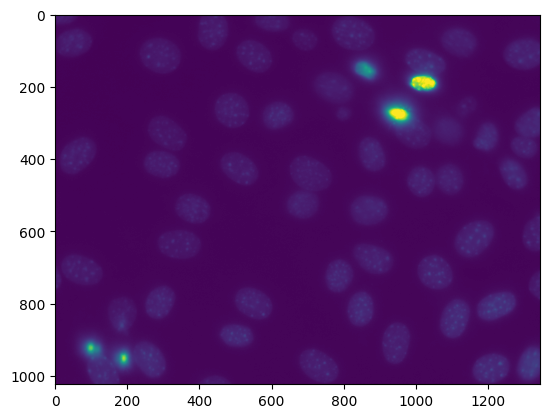

In [ ]:
import mahotas as mh
import mahotas.demos
import numpy as np
from pylab import imshow, show

f = mh.demos.nuclear_image()
f = f[:,:,0]

imshow(f)
show()

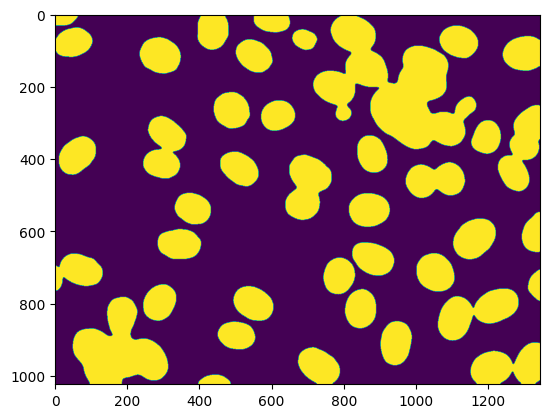

In [ ]:
f = mh.gaussian_filter(f,4)
f = (f> f.mean())

f = mh.gaussian_filter(f, 4)
f = (f> f.mean())
imshow(f)
show()

In [ ]:
labeled, n_nucleus = mh.label(f)
print('Found {} nuclei.'.format(n_nucleus))

Found 40 nuclei.


Found 40 nuclei.


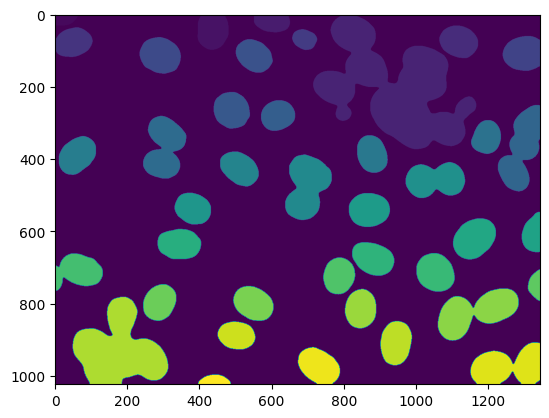

In [ ]:
labeled, n_nucleus = mh.label(f)
print('Found {} nuclei.'.format(n_nucleus))
imshow(labeled)
show()

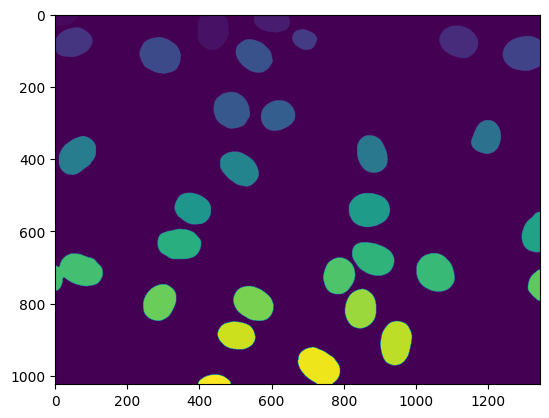

In [ ]:
sizes = mh.labeled.labeled_size(labeled)
too_big = np.where(sizes>10000)
labeled = mh.labeled.remove_regions(labeled, too_big)

sizes = mh.labeled.labeled_size(labeled)
too_big = np.where(sizes>10000)
labeled = mh.labeled.remove_regions(labeled, too_big)

imshow(labeled)
show()

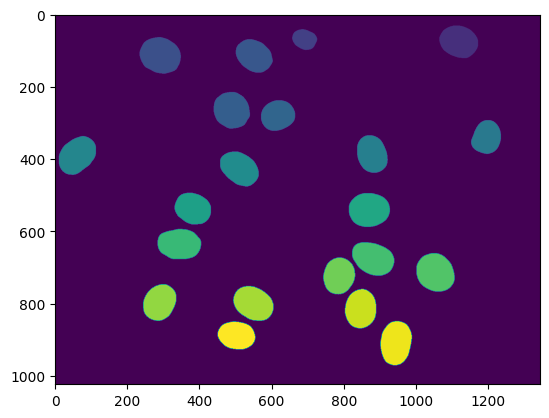

In [ ]:
labeled = mh.labeled.remove_bordering(labeled)

labeled = mh.labeled.remove_bordering(labeled)
imshow(labeled)
show()

In [ ]:
relabeled, n_left = mh.labeled.relabel(labeled)
print('after filtering and relabeling,'
'there are {} nuclei lefy.'.format(n_left))

after filtering and relabeling,there are 21 nuclei lefy.


after filtering and relabeling,there are 21 nuclei lefy.


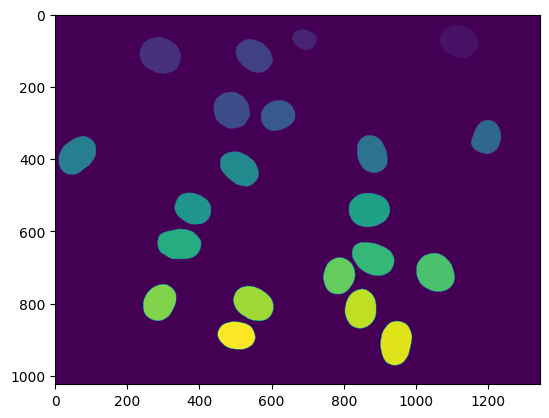

In [ ]:
relabeled, n_left = mh.labeled.relabel(labeled)
print('after filtering and relabeling,'
'there are {} nuclei lefy.'.format(n_left))

imshow(relabeled)
show()

Pada skenario ini, analisis dilakukan pada gambar mikroskopis inti sel (nuclei) menggunakan pustaka Mahotas. Gambar diambil dari dataset demo dan diproses melalui beberapa langkah, termasuk penerapan filter Gaussian untuk mengurangi noise dan membinarisasi gambar berdasarkan nilai rata-rata piksel. Proses pelabelan dilakukan untuk mendeteksi area-area terhubung yang merepresentasikan inti sel, dan objek yang terlalu besar dihapus agar hanya inti sel yang relevan dipertahankan. Selanjutnya, objek di tepi gambar juga dihapus untuk menghindari artefak. Setelah itu, gambar direlabel ulang untuk menghasilkan jumlah inti sel akhir yang terdeteksi dengan benar. Visualisasi dilakukan pada setiap tahap untuk memeriksa hasil transformasi.

### Skenario 13.2

In [ ]:
from skimage import data
from skimage import color
from skimage.filters import meijering, sato, frangi, hessian
import matplotlib.pyplot as plt

In [ ]:
def identity(image, **kwargs):
  """return the original image, ignoring anykwargs."""
  return image


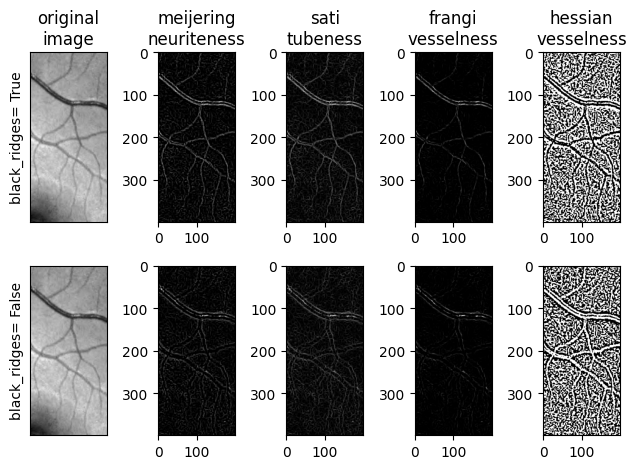

In [ ]:
image = color.rgb2gray(data.retina()) [300:700,700:900]
cmap = plt.cm.gray
kwargs = {'sigmas':[1],'mode':'reflect'}
fig, axes = plt.subplots(2,5)
for i, black_ridges in enumerate([1,0]):
  for j, func in enumerate([identity,meijering,sato,frangi,hessian]):
    kwargs['black_ridges'] = black_ridges
    result = func(image, **kwargs)
    axes[i,j].imshow(result, cmap=cmap, aspect='auto')
    if i == 0:
      axes[i,j].set_title(['original\nimage','meijering\nneuriteness','sati\ntubeness','frangi\nvesselness','hessian\nvesselness'][j])
    if j ==0:
      axes[i,j].set_ylabel('black_ridges= ' + str(bool(black_ridges)))
      axes[i,j].set_xticks([])
      axes[i,j].set_yticks([])

plt.tight_layout()
plt.show()

Skenario ini mengeksplorasi metode pendeteksian fitur berbasis filter menggunakan pustaka Skimage pada gambar retina. Gambar diubah ke grayscale, dan berbagai filter seperti Meijering, Sato, Frangi, dan Hessian diterapkan untuk menyoroti struktur tertentu seperti pembuluh darah atau neurit. Perbandingan dilakukan antara kondisi dengan dan tanpa parameter black_ridges. Filter-filter ini mempermudah identifikasi struktur kompleks dalam gambar medis, dengan visualisasi hasil masing-masing metode disusun dalam grid untuk analisis komparatif.

### Skenario 13.3

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.exposure import histogram

In [ ]:
coins = data.coins()
hist, hist_centers = histogram(coins)

Text(0.5, 1.0, 'histogram of gray values')

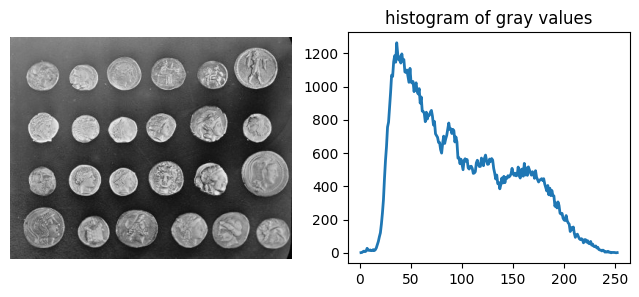

In [ ]:
fig,axes = plt.subplots(1, 2, figsize=(8,3))
axes[0].imshow(coins, cmap=plt.cm.gray)
axes[0].axis('off')

axes[1].plot(hist_centers, hist, lw=2)
axes[1].set_title('histogram of gray values')

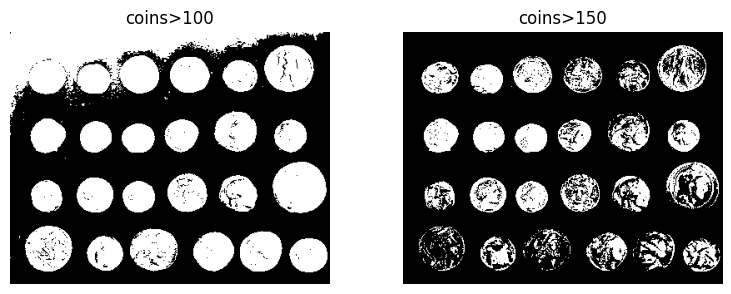

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8,3), sharey=True)

axes[0].imshow(coins>100, cmap=plt.cm.gray)
axes[0].set_title('coins>100')

axes[1].imshow(coins>150, cmap=plt.cm.gray)
axes[1].set_title('coins>150')

for a in axes:
  a.axis('off')

plt.tight_layout()

(-0.5, 383.5, 302.5, -0.5)

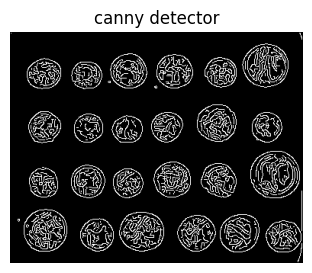

In [ ]:
from skimage.feature import canny

edges = canny(coins)
fig, ax = plt.subplots(figsize=(4,3))

ax.imshow(edges, cmap=plt.cm.gray)
ax.set_title('canny detector')
ax.axis('off')

(-0.5, 383.5, 302.5, -0.5)

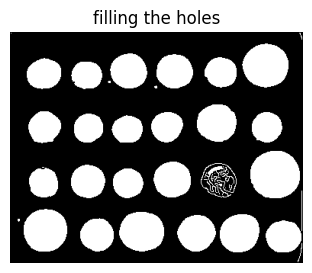

In [ ]:
from scipy import ndimage as ndi

fill_coins = ndi.binary_fill_holes(edges)
fig, ax = plt.subplots(figsize=(4,3))

ax.imshow(fill_coins, cmap=plt.cm.gray)
ax.set_title('filling the holes')
ax.axis('off')

(-0.5, 383.5, 302.5, -0.5)

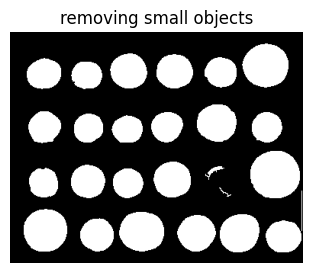

In [ ]:
from skimage import morphology

coins_cleaned = morphology.remove_small_objects(fill_coins,21)
fig, ax = plt.subplots(figsize=(4,3))

ax.imshow(coins_cleaned, cmap=plt.cm.gray)
ax.set_title('removing small objects')
ax.axis('off')

(-0.5, 383.5, 302.5, -0.5)

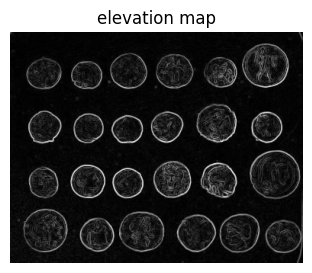

In [ ]:
from skimage.filters import sobel

elevation_map = sobel(coins)
fig, ax = plt.subplots(figsize=(4,3))

ax.imshow(elevation_map, cmap=plt.cm.gray)
ax.set_title('elevation map')
ax.axis('off')

(-0.5, 383.5, 302.5, -0.5)

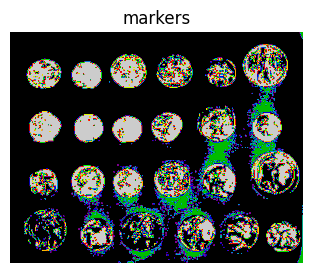

In [ ]:
markers = np.zeros_like(coins)
markers[coins < 30] = 1
markers[coins > 150] = 2
fig, ax = plt.subplots(figsize=(4,3))
ax.imshow(markers, cmap=plt.cm.nipy_spectral)
ax.set_title('markers')
ax.axis('off')

(-0.5, 383.5, 302.5, -0.5)

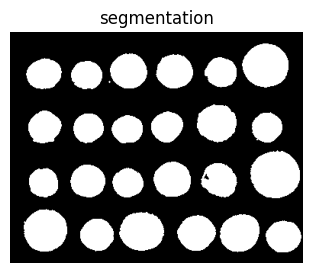

In [ ]:
from skimage import segmentation
segmentation_coins = segmentation.watershed(elevation_map, markers)

fig,ax = plt.subplots(figsize=(4,3))

ax.imshow(segmentation_coins, cmap=plt.cm.gray)

ax.set_title('segmentation')
ax.axis('off')

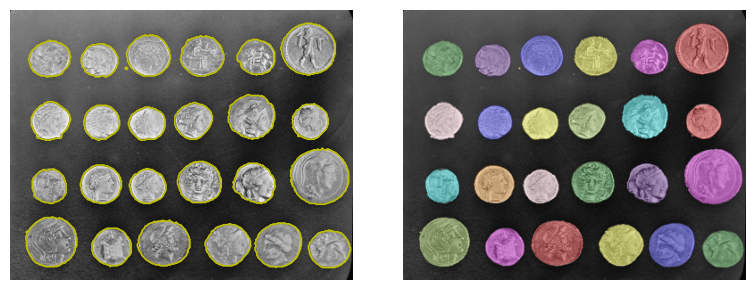

In [ ]:
from skimage.color import label2rgb
segmentation_coins = ndi.binary_fill_holes(segmentation_coins - 1)
labeled_coins, _ = ndi.label(segmentation_coins)

image_label_overlay = label2rgb(labeled_coins, image=coins, bg_label=0)

fig,axes = plt.subplots(1,2, figsize=(8,3), sharey=True)
axes[0].imshow(coins, cmap=plt.cm.gray)
axes[0].contour(segmentation_coins,[0.5],linewidths=1.2,colors='y')
axes[1].imshow(image_label_overlay)

for a in axes:
  a.axis('off')

plt.tight_layout()
plt.show()

Skenario ini bertujuan untuk mendeteksi dan menganalisis koin pada gambar menggunakan berbagai teknik dari Skimage. Histogram nilai intensitas dihitung untuk memahami distribusi piksel, dan thresholding diterapkan untuk memisahkan koin dari latar belakang. Deteksi tepi menggunakan metode Canny membantu mengidentifikasi batas objek, sementara lubang pada objek diisi untuk mendapatkan bentuk lengkap koin. Objek kecil dihapus untuk meningkatkan akurasi deteksi, dan peta elevasi dihitung menggunakan filter Sobel untuk membantu segmentasi berbasis watershed. Markers ditentukan berdasarkan intensitas piksel untuk segmentasi, dan hasil akhir divisualisasikan dengan overlay label pada gambar asli, yang menunjukkan segmentasi koin yang lebih baik.

### Skenario 13.4

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.data import astronaut
from skimage.color import rgb2gray
from skimage.filters import sobel
from skimage.segmentation import felzenszwalb, slic, quickshift, watershed
from skimage.segmentation import mark_boundaries
from skimage.util import img_as_float

In [ ]:
img = img_as_float(astronaut()[::2, ::2])
segments_fz = felzenszwalb(img, scale=100, sigma=0.5, min_size=50)
segments_slic = slic(img, n_segments=250, compactness=10, sigma=1,start_label=1)

segments_quick = quickshift(img, kernel_size=3, max_dist=6, ratio=0.5)

In [ ]:
gradient = sobel(rgb2gray(img))
segments_watershed = watershed(gradient, markers=250,compactness=0.001)

In [ ]:
print('Felzenszwalb number of segments: {}'.format(len(np.unique(segments_fz))))
print('SLIC number of segments: {}'.format(len(np.unique(segments_slic))))
print(f'Quickshift number of segments: {len(np.unique(segments_quick))}')

Felzenszwalb number of segments: 194
SLIC number of segments: 196
Quickshift number of segments: 695


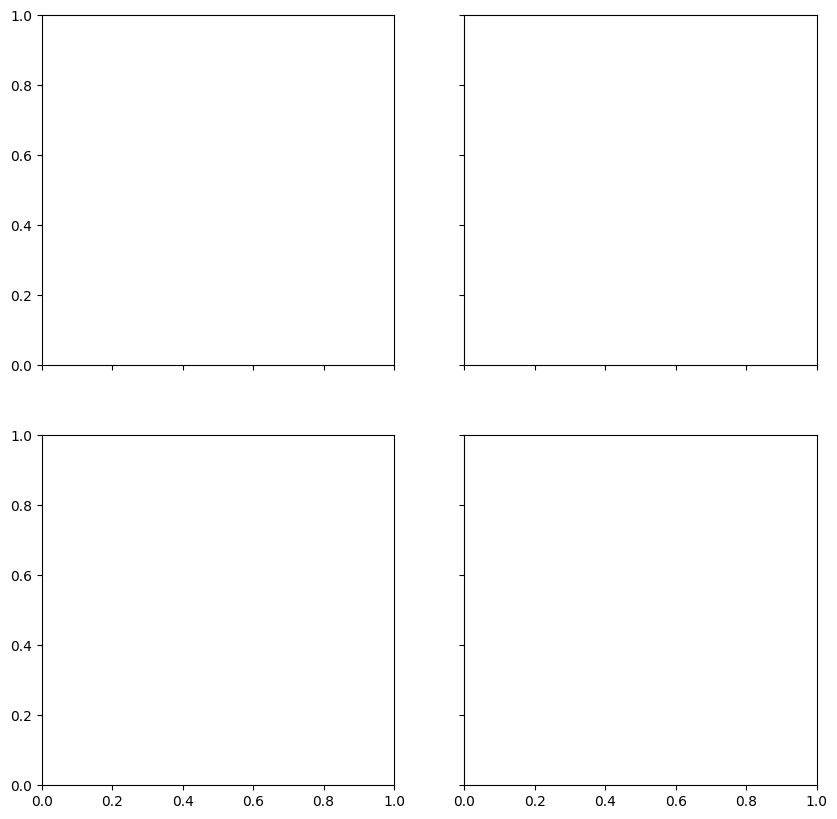

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(10,10), sharex=True, sharey=True)


In [ ]:
ax[0,0].imshow(mark_boundaries(img, segments_fz))
ax[0,0].set_title('Felzenszwalb methods')
ax[0,1].imshow(mark_boundaries(img, segments_slic))
ax[0,1].set_title('SLIC')
ax[1,0].imshow(mark_boundaries(img, segments_quick))
ax[1,0].set_title('quickshift')
ax[1,1].imshow(mark_boundaries(img, segments_watershed))
ax[1,1].set_title('compact watershed')

Text(0.5, 1.0, 'compact watershed')

In [ ]:
for a in ax.ravel():
  a.set_axis_off()

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

Skenario ini menggunakan metode segmentasi pada gambar astronot dengan pustaka Skimage. Empat algoritme segmentasi, yaitu Felzenszwalb, SLIC, Quickshift, dan watershed, diterapkan untuk membagi gambar menjadi beberapa segmen berdasarkan parameter seperti warna, tekstur, atau gradien. Segmentasi Felzenszwalb menghasilkan segmen berdasarkan hierarki area, sementara SLIC menggunakan metode superpixel untuk kompak dan seragam. Quickshift memanfaatkan gradien spasial untuk membentuk segmen, sedangkan watershed memanfaatkan peta gradien sebagai pemandu. Jumlah segmen yang dihasilkan oleh setiap metode dihitung dan divisualisasikan, menunjukkan perbedaan pendekatan dalam pembagian area gambar menjadi wilayah yang lebih kecil.